In [1]:
from scipy.io import loadmat

import numpy as np
import matplotlib.pyplot as plt
# importing rastermap
# (this will be slow the first time since it is compiling the numba functions)
from rastermap import Rastermap, utils
from scipy.stats import zscore

import os

In [2]:
filepath = r'C:\Users\munib\Documents\Economo-Lab\data\rastermap'
filename = 'MAH24_2024-06-11_RasterMapData.mat'
data = loadmat(os.path.join(filepath,filename))
# nTimeEachTrial = data['nTimeEachTrial']
# motionSVD = data['videoSVD']
# neuralActivity = data['neuralActivity']
# dt = data['dt'][0][0]

anm = str(data['anm'][0])
session_date = str(data['sessiondate'][0])
spks = data['spks'] # binned firing rates of size (neurons x time bins)
trial_start = data['trialstart']
sample = data['sample']
delay = data['delay']
gocue = data['gocue']
dt = data['dt'][0]
tedges = data['tedges']
tagged = data['tagged']

In [3]:
spks.shape

(133, 154791)

In [4]:
model = Rastermap(n_clusters=None, # None turns off clustering and sorts single neurons 
                  n_PCs=64, # use fewer PCs than neurons
                  locality=0.1, # some locality in sorting (this is a value from 0-1)
                  time_lag_window=15, # use future timepoints to compute correlation
                  grid_upsample=0, # 0 turns off upsampling since we're using single neurons
                ).fit(spks)
y = model.embedding # neurons x 1
isort = model.isort

2024-11-11 15:56:30,652 [INFO] normalizing data across axis=1
2024-11-11 15:56:30,916 [INFO] projecting out mean along axis=0
2024-11-11 15:56:31,084 [INFO] data normalized, 0.43sec
2024-11-11 15:56:31,085 [INFO] sorting activity: 133 valid samples by 154791 timepoints
2024-11-11 15:56:55,860 [INFO] n_PCs = 64 computed, 25.21sec
2024-11-11 15:56:55,975 [INFO] skipping clustering, n_clusters is None
2024-11-11 15:57:24,828 [INFO] clusters sorted, time 54.18sec
2024-11-11 15:57:25,310 [INFO] rastermap complete, time 54.66sec


(np.float64(-0.5), np.float64(0.5), np.float64(132.5), np.float64(-0.5))

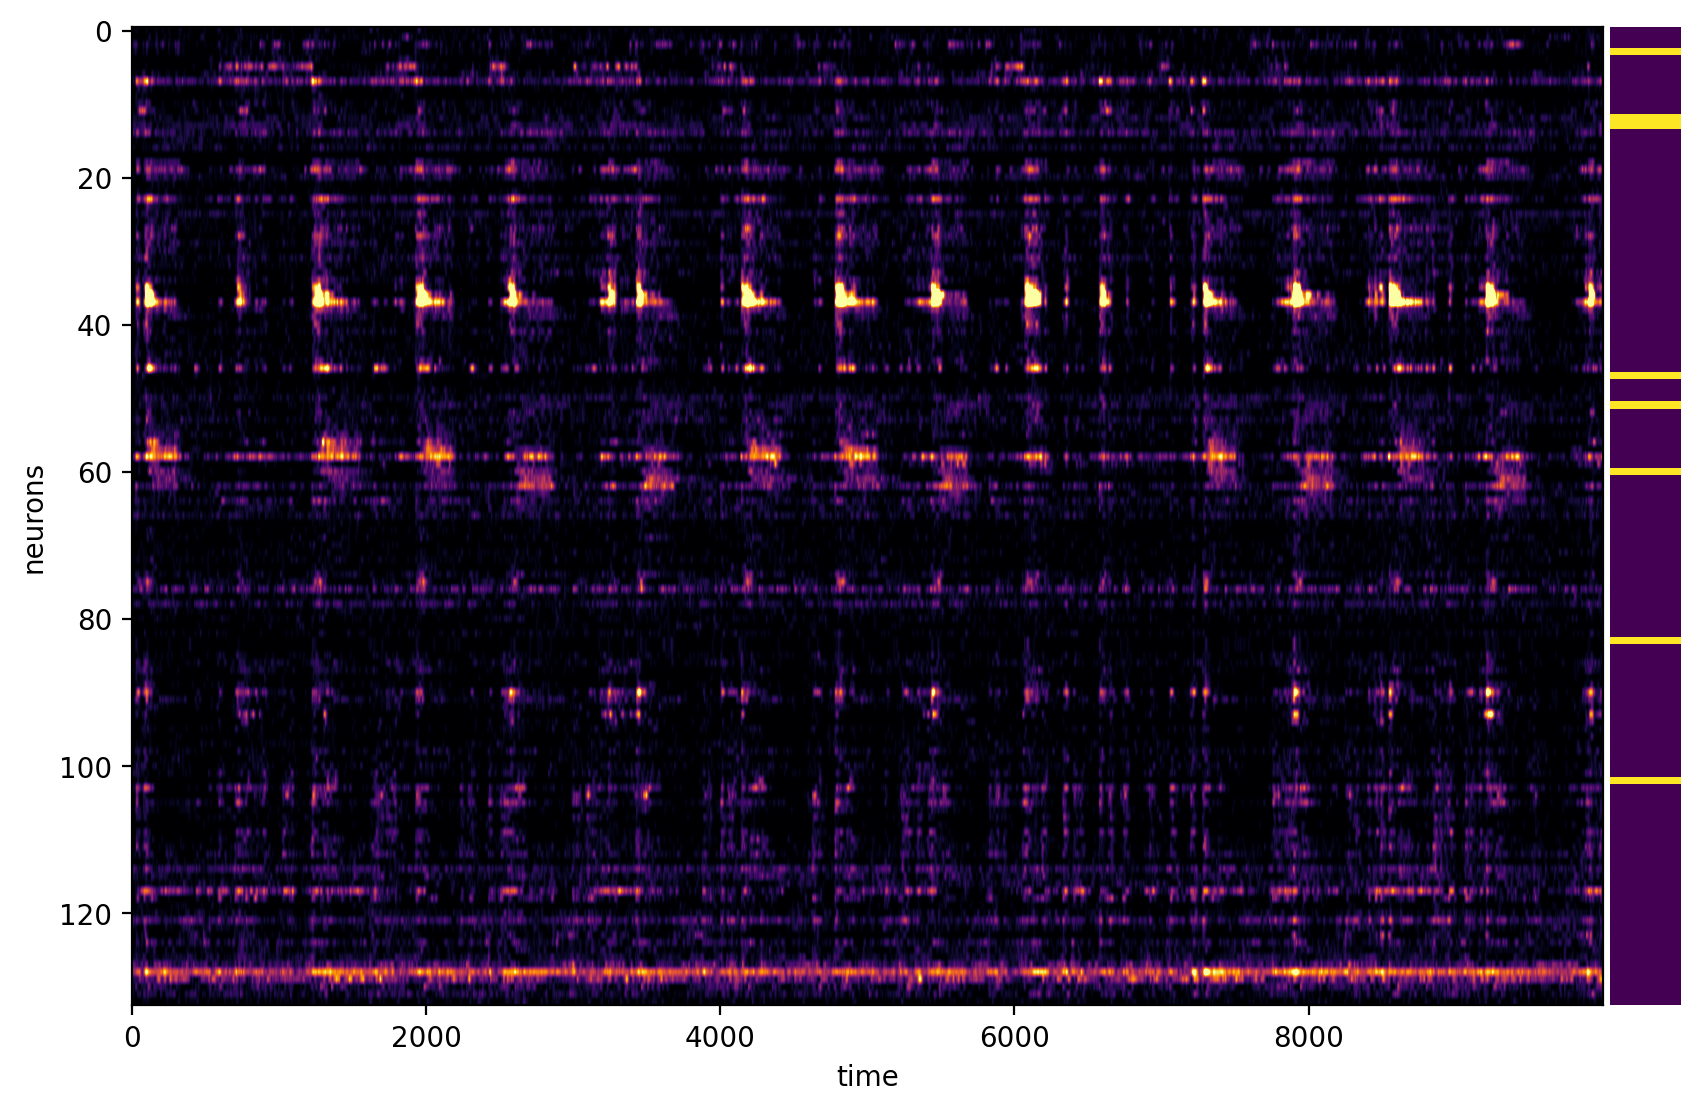

In [25]:
# timepoints to visualize
xmin = 70000
xmax = xmin + 10000

# make figure with grid for easy plotting
fig = plt.figure(figsize=(12,8), dpi=200)
grid = plt.GridSpec(10, 24, figure=fig, wspace = 0.1, hspace = 0.4)


# plot sorted neural activity
ax = plt.subplot(grid[2:, :-5])
ax.imshow(spks[isort, xmin:xmax], cmap="inferno",vmin=0,vmax=100,aspect='auto')
# ax.imshow(spks[isort, xmin:xmax], cmap="inferno", vmin=0, vmax=1.2, aspect="auto")
ax.set_xlabel("time")
ax.set_ylabel("neurons")

# excitatory cells in yellow, and inhibitory cells in dark blue
# (could replace this with a colorbar or other property)
ax = plt.subplot(grid[2:, -5])
ax.imshow(tagged[isort, np.newaxis],
          cmap="viridis", aspect="auto")
ax.axis("off")

In [9]:
isort

array([ 32,  93,  12,  27,   8,   9,   6,  23,  58,  28,  29,  31,  34,
        33,  21,  22,  18, 120,  17,  20,  51,  52,  42,  40,  45,  24,
        66,  11, 102,  14,  76,  75,  88,  94,  56,  55, 109,  95,  13,
        15,  16,  19,  60,   5,  64,  49,  48,  91, 108,  79,  73,  72,
       105,  83,  97,  98, 118, 110,  85,  81,  80,  67,  96,  74, 104,
       101,  61,  41,  43,  62,  63,  54,  99, 112, 116,  82,  57,   4,
         3,  90, 119,  35, 111, 107, 106,  77,  59,   2,  37,  53,  36,
        65,   7,  68,  50,   1, 114, 113, 117, 115,  84, 103,  78,  46,
        69,  39,  47,  10,  30,  38,  89,  86,  70,  25,  71,  26,  87,
       100,  44,  92,   0])

In [20]:
import numpy as np

In [21]:
np.max(spks)

np.float64(469.48441500506596)

In [22]:
np.min(spks)

np.float64(0.0)